## Reinforcement Learning


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

Graph Definition

In [10]:
edges = [
    (0, 1), (1, 5), (5, 6), (5, 4), (1, 2),
    (1, 3), (9, 10), (2, 4), (0, 6), (6, 7),
    (8, 9), (7, 8), (1, 7), (3, 9), (10, 8), (10, 10)
]
goal = 10
MATRIX_SIZE = 11

Graph Visualization

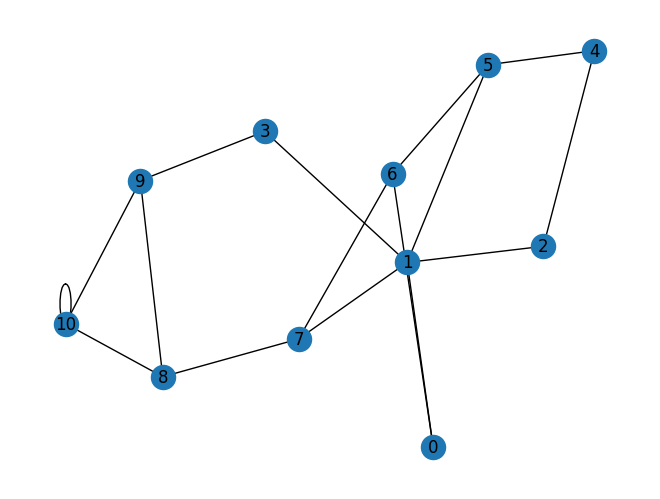

In [11]:
G = nx.Graph()
G.add_edges_from(edges)

pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True)
plt.show()

Reward Matrix R

In [12]:
R = np.ones((MATRIX_SIZE, MATRIX_SIZE)) * -1

for (i, j) in edges:
    if j == goal:
        R[i][j] = 100
    else:
        R[i][j] = 0

    if i == goal:
        R[j][i] = 100
    else:
        R[j][i] = 0

R[goal][goal] = 100

Q Matrix Initialization

In [13]:
Q = np.zeros((MATRIX_SIZE, MATRIX_SIZE))
gamma = 0.75

Helper Functions

In [14]:
def available_actions(state):
    return np.where(R[state] >= 0)[0]

def sample_next_action(actions):
    return np.random.choice(actions)

def update(current_state, action):
    max_q = np.max(Q[action])
    Q[current_state][action] = R[current_state][action] + gamma * max_q

Training

In [15]:
scores = []

for _ in range(1000):
    state = np.random.randint(0, MATRIX_SIZE)
    actions = available_actions(state)
    action = sample_next_action(actions)

    update(state, action)

    if np.max(Q) > 0:
        scores.append(np.sum(Q / np.max(Q) * 100))
    else:
        scores.append(0)

Normalize Q

In [16]:
Q_normalized = Q / np.max(Q) * 100

print("Trained Q Matrix:")
print(Q_normalized)

Trained Q Matrix:
[[  0.          42.18498824   0.           0.           0.
    0.          42.18498824   0.           0.           0.
    0.        ]
 [ 31.62841506   0.          31.62841506  56.24665099   0.
   31.62841506   0.          56.22829344   0.           0.
    0.        ]
 [  0.          42.18498824   0.           0.          23.72131129
    0.           0.           0.           0.           0.
    0.        ]
 [  0.          42.17122008   0.           0.           0.
    0.           0.           0.           0.          75.
    0.        ]
 [  0.           0.          31.62841506   0.           0.
   31.62841506   0.           0.           0.           0.
    0.        ]
 [  0.          42.18498824   0.           0.          23.72131129
    0.          42.17122008   0.           0.           0.
    0.        ]
 [ 31.62841506   0.           0.           0.           0.
   31.63874118   0.          56.24665099   0.           0.
    0.        ]
 [  0.          42.18498824 

Plot Learning Curve

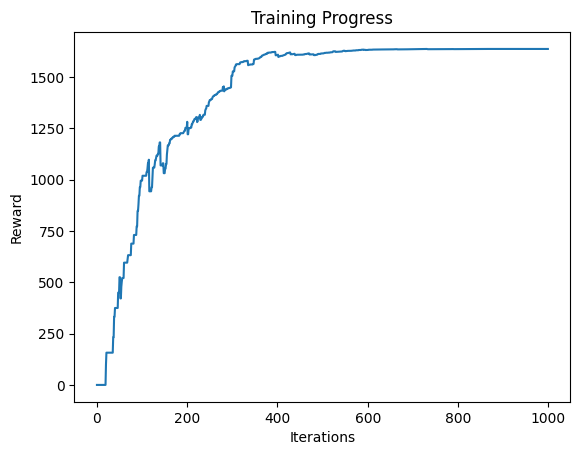

In [17]:
plt.plot(scores)
plt.xlabel("Iterations")
plt.ylabel("Reward")
plt.title("Training Progress")
plt.show()

 Optimal Path

In [18]:
current_state = 2
steps = [current_state]

while current_state != goal:
    next_step = np.argmax(Q[current_state])
    steps.append(next_step)
    current_state = next_step

print("Optimal Path:")
print(steps)

Optimal Path:
[2, np.int64(1), np.int64(3), np.int64(9), np.int64(10)]
